In [3]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import os

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [6]:
import os

# Buscar donde está la carpeta mitdb
for root, dirs, files in os.walk('C:/Users/josem'):
    for file in files:
        if file == '100.dat':
            print(os.path.join(root, file))

C:/Users/josem\AppData\Local\Packages\microsoft.windowscommunicationsapps_8wekyb3d8bbwe\LocalState\Files\S0\4\EFMData\100.dat
C:/Users/josem\mitdb\100.dat


In [7]:
record = wfdb.rdrecord('C:/Users/josem/mitdb/100')
annotation = wfdb.rdann('C:/Users/josem/mitdb/100', 'atr')

print(f"Muestras totales: {len(record.p_signal)}")
print(f"Anotaciones: {len(annotation.symbol)}")
print(f"Tipos de latidos: {set(annotation.symbol)}")

Muestras totales: 650000
Anotaciones: 2274
Tipos de latidos: {'A', 'V', 'N', '+'}


In [8]:
# Extraer segmentos de cada latido
ventana = 100  # muestras antes y después del latido
señal = record.p_signal[:, 0]
X = []
y = []

for i, (muestra, simbolo) in enumerate(zip(annotation.sample, annotation.symbol)):
    if simbolo in ['N', 'V', 'A']:
        if muestra > ventana and muestra < len(señal) - ventana:
            segmento = señal[muestra - ventana: muestra + ventana]
            X.append(segmento)
            y.append(simbolo)

X = np.array(X)
y = np.array(y)

print(f"Total latidos: {len(y)}")
print(f"Distribución: {pd.Series(y).value_counts()}")

Total latidos: 2271
Distribución: N    2237
A      33
V       1
Name: count, dtype: int64


In [9]:
# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenar el modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")
print(f"Datos de entrenamiento: {len(X_train)}")
print(f"Datos de prueba: {len(X_test)}")

Modelo entrenado correctamente
Datos de entrenamiento: 1816
Datos de prueba: 455


Reporte de clasificación:
              precision    recall  f1-score   support

           A       1.00      0.43      0.60         7
           N       0.99      1.00      1.00       448

    accuracy                           0.99       455
   macro avg       1.00      0.71      0.80       455
weighted avg       0.99      0.99      0.99       455



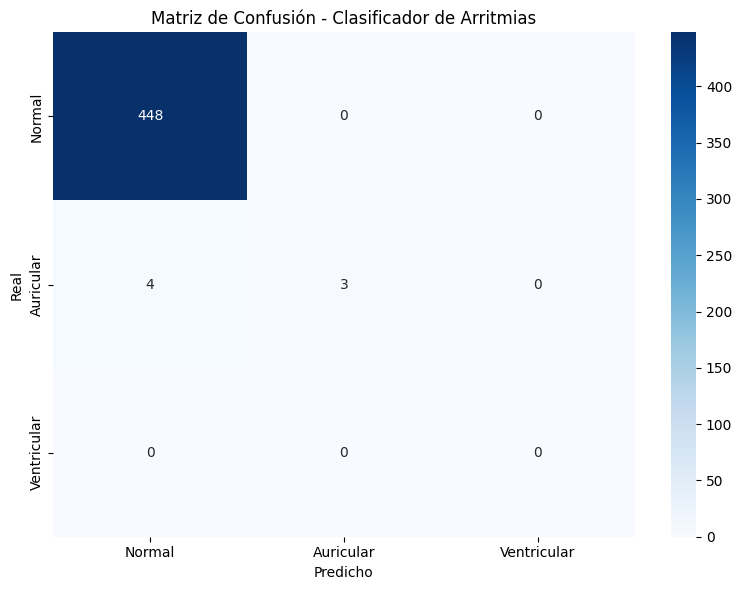

In [10]:
# Evaluar el modelo
y_pred = modelo.predict(X_test)

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=['N', 'A', 'V'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Auricular', 'Ventricular'],
            yticklabels=['Normal', 'Auricular', 'Ventricular'])
plt.title('Matriz de Confusión - Clasificador de Arritmias')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

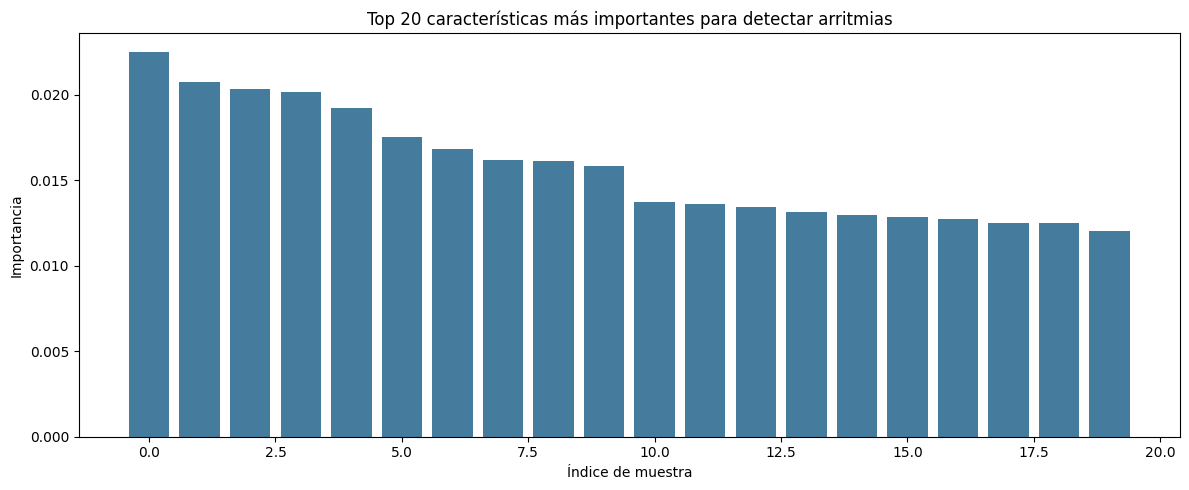

In [11]:
# Importancia de características
importancias = modelo.feature_importances_
indices = np.argsort(importancias)[::-1][:20]

plt.figure(figsize=(12, 5))
plt.bar(range(20), importancias[indices], color='#457b9d')
plt.title('Top 20 características más importantes para detectar arritmias')
plt.xlabel('Índice de muestra')
plt.ylabel('Importancia')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()